In [780]:
import numpy as np
import pandas as pd

# pandas

- numpy는 벡터/메트릭스/텐서(3차원 이상)를 구분하지 않음. -> 오직 array로 표현  
- pandas는 벡터와 메트릭스를 정확하게 구분  
- 다만 pandas를 이용해서 텐서 이상을 정의하거나 연산하지는 않음.  
- 즉, 일반적으로 pandas는 메트릭스 연산을 위해서 사용.  
- 2차원 데이터(메트릭스)는 엑셀 && RDB 데이터를 의미  
- 일반적으로 머신러닝은 2차원 데이터를 학습하는 모델!!(참고로 3차원 이상의 데이터 학습하는 모델이 딥러닝임.->이때 pandas못쓰니까 pytorch같은거 쓰는 거임.)

## pandas 기본

### 1. 데이터 구조

#### 1-1. Series -1차원 데이터 (벡터)

##### 1-1-1. series 생성

In [781]:
data = {
    "a":1,"b":2,"c":3    
}

pd.Series(data=data, dtype=np.int16) #key -> index, value ->data값 으로 매칭되어 변환됨.

a    1
b    2
c    3
dtype: int16

In [782]:
# 만약 data가 스칼라 값들로 주어졌다면? 인덱스 값이 주어져야함.
pd.Series(5.0, index = ['a','b','c','d','e'])

a    5.0
b    5.0
c    5.0
d    5.0
e    5.0
dtype: float64

In [783]:
arr = pd.Series(data=np.random.randn(5)) # randn -> rand(랜덤) n(정규분포)
arr

0   -0.686818
1    0.614600
2   -0.565416
3    2.111063
4    0.222916
dtype: float64

##### 1-1-2. 슬라이싱/인덱스

In [784]:
arr[:3]

0   -0.686818
1    0.614600
2   -0.565416
dtype: float64

In [785]:
arr[1]

np.float64(0.6145996519745078)

In [786]:
cond = arr > arr.mean()
arr[cond]

1    0.614600
3    2.111063
dtype: float64

#### 1-2 DataFrame - 2차원 데이터(metrix)

##### 1-2-1. DataFrame 생성

- 시리즈에선 키가 인덱스 이름이었음.
- 데이터프레임에선 키가 컬럼 이름임.

In [787]:
data = {
    'one' : pd.Series(data=np.random.randn(5)),
    'two' : pd.Series(data=np.random.randn(5))
}

df = pd.DataFrame(data=data)
df

,one,two
0,-0.423041,-0.630450
1,-0.225820,-0.246551
2,1.089370,1.689318
3,-0.062490,0.257988
4,1.474885,0.724259


In [788]:
data = {
    'one' : pd.Series(data=np.random.randn(5),index=['a','b','c','d','e']),
    'two' : pd.Series(data=np.random.randn(5),index=['a','b','c','d','e'])
}

df = pd.DataFrame(data=data)
df

,one,two
a,1.213349,0.978712
b,0.211536,-1.022250
c,0.559321,-0.462770
d,0.032276,0.548343
e,0.272205,1.235236


In [789]:
df.index, df.shape

(Index(['a', 'b', 'c', 'd', 'e'], dtype='str'), (5, 2))

In [790]:
data2 = [{"a": 1, "b": 2}, {"a": 5, "b": 10, "c": 20}]
pd.DataFrame(data=data2)

,a,b,c
0,1,2,NaN
1,5,10,20.0


In [791]:
data2 = [{"a": 1, "b": 2}, {"a": 5, "b": 10, "c": 20}]
pd.DataFrame(data=data2, index = ['one','two'])

,a,b,c
one,1,2,NaN
two,5,10,20.0


In [792]:
ser = pd.Series(range(3),index=list('abc'), name='ser')
ser_df = pd.DataFrame(ser)
ser_df

,ser
a,0
b,1
c,2


In [793]:
ser_df.shape

(3, 1)

>dictionary형태를 dataframe으로 바꾸기

In [794]:
data = {
    "one" : [1,2,3,4],
    "two" : [5,6,7,8]
}
# pd.DataFrame(data) 이렇게는 못만듬
df = pd.DataFrame.from_dict(data)
df

,one,two
0,1,5
1,2,6
2,3,7
3,4,8


##### 1-2-2 데이터 변환

###### 1. pd.DataFrame.to_dict()

In [795]:
df.to_dict()

{'one': {0: 1, 1: 2, 2: 3, 3: 4}, 'two': {0: 5, 1: 6, 2: 7, 3: 8}}

In [796]:
df.to_dict('series')

{'one': 0    1
 1    2
 2    3
 3    4
 Name: one, dtype: int64,
 'two': 0    5
 1    6
 2    7
 3    8
 Name: two, dtype: int64}

In [797]:
df.to_dict('records')

[{'one': 1, 'two': 5},
 {'one': 2, 'two': 6},
 {'one': 3, 'two': 7},
 {'one': 4, 'two': 8}]

###### 2. pd.DataFrame.to_json()

In [798]:
df.to_json()

'{"one":{"0":1,"1":2,"2":3,"3":4},"two":{"0":5,"1":6,"2":7,"3":8}}'

In [799]:
df.to_json(orient="records")

'[{"one":1,"two":5},{"one":2,"two":6},{"one":3,"two":7},{"one":4,"two":8}]'

###### 2. pd.DataFrame.to_csv()

In [800]:
df.to_csv()

',one,two\r\n0,1,5\r\n1,2,6\r\n2,3,7\r\n3,4,8\r\n'

##### 1-2-3 컬럼 선택, 추가, 삭제

In [801]:
data = {
    "one": pd.Series([1.0, 2.0, 3.0], index=["a", "b", "c"]),
    "two": pd.Series([1.0, 2.0, 3.0, 4.0], index=["a", "b", "c", "d"]),
}

df = pd.DataFrame(data=data)
df

,one,two
a,1.0,1.0
b,2.0,2.0
c,3.0,3.0
d,NaN,4.0


In [802]:
df['one']

a    1.0
b    2.0
c    3.0
d    NaN
Name: one, dtype: float64

In [803]:
df['three'] = df['one'] + df['two']

In [804]:
df

,one,two,three
a,1.0,1.0,2.0
b,2.0,2.0,4.0
c,3.0,3.0,6.0
d,NaN,4.0,NaN


In [805]:
df['one'] > 1

a    False
b     True
c     True
d    False
Name: one, dtype: bool

In [806]:
#row 필터링
df[df['one']>1]

,one,two,three
b,2.0,2.0,4.0
c,3.0,3.0,6.0


In [807]:
df['flag'] = df['one'] > 1
df

,one,two,three,flag
a,1.0,1.0,2.0,False
b,2.0,2.0,4.0,True
c,3.0,3.0,6.0,True
d,NaN,4.0,NaN,False


In [808]:
del df['two']
df

,one,three,flag
a,1.0,2.0,False
b,2.0,4.0,True
c,3.0,6.0,True
d,NaN,NaN,False


In [809]:
three = df.pop('three')
three, type(three)

(a    2.0
 b    4.0
 c    6.0
 d    NaN
 Name: three, dtype: float64,
 pandas.Series)

In [810]:
df.columns = ['1','1_flag']
df

,1,1_flag
a,1.0,False
b,2.0,True
c,3.0,True
d,NaN,False


In [811]:
df.columns = ['col_'+ col for col in df.columns]
df

,col_1,col_1_flag
a,1.0,False
b,2.0,True
c,3.0,True
d,NaN,False


In [812]:
#특정 위치에 컬럼 추가
df.insert(1, 'bar', df['col_1'])
df

,col_1,bar,col_1_flag
a,1.0,1.0,False
b,2.0,2.0,True
c,3.0,3.0,True
d,NaN,NaN,False


##### 1-2-4 데이터 선택(iris 데이터 사용)

In [813]:
import seaborn as sns

In [814]:
#학습용 데이터 셋 로드
iris = sns.load_dataset('iris')
iris.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [815]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [816]:
iris.shape

(150, 5)

In [817]:
iris['species'].unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [818]:
iris['species'].nunique()

3

In [819]:
iris['species'].mode()

0        setosa
1    versicolor
2     virginica
Name: species, dtype: str

In [820]:
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [821]:
iris['species'].describe()

count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object

In [822]:
cond = iris['sepal_length'] < 5
iris[cond].head()

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
6,4.6,3.4,1.4,0.3,setosa
8,4.4,2.9,1.4,0.2,setosa


In [823]:
#setosa의 seapal_length 평균 구하기
cond = iris['species'] == 'setosa'
iris[cond]['sepal_length'].mean()

np.float64(5.006)

In [824]:
#setosa에서 sepal_width 가 3.0인것만 추출하고싶음.
iris[(iris['species']=='setosa') & (iris['sepal_width'] == 3.0)]

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa
12,4.8,3.0,1.4,0.1,setosa
13,4.3,3.0,1.1,0.1,setosa
25,5.0,3.0,1.6,0.2,setosa
38,4.4,3.0,1.3,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa


In [825]:
#setosa중에서 sepal_width가 3.5랑 3.2만추출

cond = (iris['sepal_width'].isin([3.2,3.5])) & (iris['species'] == 'setosa')
iris[cond]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
17,5.1,3.5,1.4,0.3,setosa
27,5.2,3.5,1.5,0.2,setosa
29,4.7,3.2,1.6,0.2,setosa
35,5.0,3.2,1.2,0.2,setosa
36,5.5,3.5,1.3,0.2,setosa
40,5.0,3.5,1.3,0.3,setosa
42,4.4,3.2,1.3,0.2,setosa
43,5.0,3.5,1.6,0.6,setosa


In [826]:
#setosa 아니면서 너비가 3.5,3.2아닌거 조회해줘


iris[~(iris['species'] == 'setosa') & ~(iris['sepal_width'].isin([3.2,3.5]))]

,sepal_length,sepal_width,petal_length,petal_width,species
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
55,5.7,2.8,4.5,1.3,versicolor
56,6.3,3.3,4.7,1.6,versicolor
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [827]:
#행 조회
iris.iloc[4]

sepal_length       5.0
sepal_width        3.6
petal_length       1.4
petal_width        0.2
species         setosa
Name: 4, dtype: object

In [828]:
iris.iloc[[1,2,-1]] # -1은 마지막 행

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
149,5.9,3.0,5.1,1.8,virginica


In [829]:
#행과 열 조회
iris.iloc[1:4,1:3] # [row,column]

,sepal_width,petal_length
1,3.0,1.4
2,3.2,1.3
3,3.1,1.5


In [830]:
iris.iloc[[1,7],[1,4]]

,sepal_width,species
1,3.0,setosa
7,3.4,setosa


In [831]:
#컬럼 순서 바꾸기
iris[['species','sepal_width']]

,species,sepal_width
0,setosa,3.5
1,setosa,3.0
2,setosa,3.2
3,setosa,3.1
4,setosa,3.6
...,...,...
145,virginica,3.0
146,virginica,2.5
147,virginica,3.0
148,virginica,3.4


In [832]:
#위에건 그냥 조회를 하는거뿐임. 
#순서를 바꾸려면?

iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [833]:
#컬럼이름들이 리스트에 들어있잖아.
#리스트 더하기 가능한거 알지?그럼 인덱싱말고 슬라이싱으로 하면 차원줄어들 일도 없고, 안전한게 더할수있겠네?

iris[list(iris.columns[4:]) + list(iris.columns[:4])]

,species,sepal_length,sepal_width,petal_length,petal_width
0,setosa,5.1,3.5,1.4,0.2
1,setosa,4.9,3.0,1.4,0.2
2,setosa,4.7,3.2,1.3,0.2
3,setosa,4.6,3.1,1.5,0.2
4,setosa,5.0,3.6,1.4,0.2
...,...,...,...,...,...
145,virginica,6.7,3.0,5.2,2.3
146,virginica,6.3,2.5,5.0,1.9
147,virginica,6.5,3.0,5.2,2.0
148,virginica,6.2,3.4,5.4,2.3


In [834]:
#가설 : 각각의 종마다 너비와 길이가 다르지 않겠냐 를 검증하기 위해

# 1. iris 종마다 각 피처의 통계값을 알아보자
iris['species'].unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [835]:
iris[iris['species']=='setosa'].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,50.00000,50.000000,50.000000,50.000000
mean,5.00600,3.428000,1.462000,0.246000
std,0.35249,0.379064,0.173664,0.105386
min,4.30000,2.300000,1.000000,0.100000
25%,4.80000,3.200000,1.400000,0.200000
50%,5.00000,3.400000,1.500000,0.200000
75%,5.20000,3.675000,1.575000,0.300000
max,5.80000,4.400000,1.900000,0.600000


In [836]:
iris[iris['species']=='versicolor'].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,50.000000,50.000000,50.000000,50.000000
mean,5.936000,2.770000,4.260000,1.326000
std,0.516171,0.313798,0.469911,0.197753
min,4.900000,2.000000,3.000000,1.000000
25%,5.600000,2.525000,4.000000,1.200000
50%,5.900000,2.800000,4.350000,1.300000
75%,6.300000,3.000000,4.600000,1.500000
max,7.000000,3.400000,5.100000,1.800000


In [837]:
iris[iris['species']=='virginica'].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,50.00000,50.000000,50.000000,50.00000
mean,6.58800,2.974000,5.552000,2.02600
std,0.63588,0.322497,0.551895,0.27465
min,4.90000,2.200000,4.500000,1.40000
25%,6.22500,2.800000,5.100000,1.80000
50%,6.50000,3.000000,5.550000,2.00000
75%,6.90000,3.175000,5.875000,2.30000
max,7.90000,3.800000,6.900000,2.50000


In [838]:
#위에 하나씩 하는거 귀찮음. -> groupby사용
iris.groupby('species').describe()

sepal_length                                              \
                  count   mean       std  min    25%  50%  75%  max   
species                                                               
setosa             50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor         50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica          50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal_width         ... petal_length      petal_width         \
                 count   mean  ...          75%  max       count   mean   
species                        ...                                        
setosa            50.0  3.428  ...        1.575  1.9        50.0  0.246   
versicolor        50.0  2.770  ...        4.600  5.1        50.0  1.326   
virginica         50.0  2.974  ...        5.875  6.9        50.0  2.026   

                                               
                 std  min  25%  50%  75%  max  
species                                        
setosa      0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica   0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

In [839]:
#보고싶은 통계 하나만 보고싶다.
iris.groupby('species')['sepal_width'].mean()

species
setosa        3.428
versicolor    2.770
virginica     2.974
Name: sepal_width, dtype: float64

In [840]:
# 통계 여러개 보고싶으면 .agg([])
iris.groupby('species')[['sepal_width','sepal_length']].agg(['mean','min'])

sepal_width      sepal_length     
                  mean  min         mean  min
species                                      
setosa           3.428  2.3        5.006  4.3
versicolor       2.770  2.0        5.936  4.9
virginica        2.974  2.2        6.588  4.9

##### 1-2-5 데이터 형식에 기반한 열 선택

In [841]:
iris.select_dtypes(include = np.number)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [842]:
iris.select_dtypes(include='float64')

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [843]:
iris.select_dtypes(exclude=np.number)

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


## pandas 심화

In [844]:
import numpy as np
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')

### 데이터 조회

In [845]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [846]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


### NULL 확인

In [847]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [848]:
df.isnull().sum() #컬럼별 null개수 확인

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [849]:
df.isnull().sum().sum() #전체 null 개수 확인

np.int64(869)

In [850]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### 통계

In [851]:
df_num = df.select_dtypes(include=np.number)
df_obj = df.select_dtypes(exclude=np.number)

In [852]:
df.shape, df_num.shape, df_obj.shape

((891, 15), (891, 6), (891, 9))

In [853]:
df_num.columns, df_obj.columns

(Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str'),
 Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
        'alive', 'alone'],
       dtype='str'))

In [854]:
df_num['age'].median()

np.float64(28.0)

In [855]:
df_num.mean()

survived     0.383838
pclass       2.308642
age         29.699118
sibsp        0.523008
parch        0.381594
fare        32.204208
dtype: float64

In [856]:
df_num.mean(1) # 인풋파람의 default = 0임 즉 axis = 0 -> 로우삭제 컬럼별 평균, axis=1 -> 컬럼 삭제 로우별 컬럼

C:\Users\Playdata\AppData\Local\Temp\ipykernel_22348\824090798.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  df_num.mean(1) # 인풋파람의 default = 0임 즉 axis = 0 -> 로우삭제 컬럼별 평균, axis=1 -> 컬럼 삭제 로우별 컬럼


0       5.541667
1      18.713883
2       6.320833
3      15.183333
4       7.675000
         ...    
886     7.000000
887     8.500000
888     5.890000
889     9.666667
890     7.125000
Length: 891, dtype: float64

In [857]:
df_num.std() #표준편차

survived     0.486592
pclass       0.836071
age         14.526497
sibsp        1.102743
parch        0.806057
fare        49.693429
dtype: float64

In [858]:
df_num.var() #분산

survived       0.236772
pclass         0.699015
age          211.019125
sibsp          1.216043
parch          0.649728
fare        2469.436846
dtype: float64

In [859]:
#value_counts()
df_obj.columns

Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [860]:
df_obj['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [861]:
df.describe(include='all') #숫자 & 카데고리 데이터 전부에 대한 통계값

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [862]:
df.describe(include=np.number)

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [863]:
df.describe(exclude=np.number)

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


### map()

In [864]:
x = pd.Series({'one': 1, 'two' :2, 'three':3})
y = pd.Series({1:'traingle', 2: 'square', 3: 'circle'})

In [865]:
x

one      1
two      2
three    3
dtype: int64

In [866]:
y

1    traingle
2      square
3      circle
dtype: str

In [867]:
x.map(y)

one      traingle
two        square
three      circle
dtype: str

In [868]:
y.map(x)

1   NaN
2   NaN
3   NaN
dtype: float64

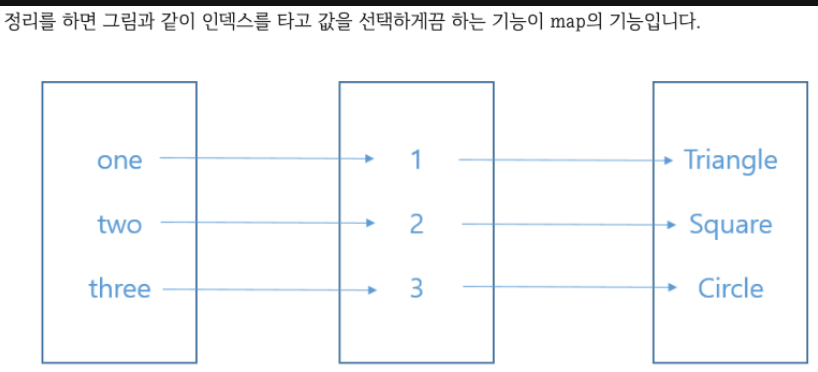

In [869]:
df['sex'].head()

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str

In [870]:
replace_dict = {'male' : 1, 'female' : 0}
df['sex'].map(replace_dict).head()

0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64

In [871]:
df['sex'].map(lambda value : 1 if value =='male' else 0)[:5]

0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64

### apply()

In [872]:
df_tmp = pd.DataFrame(np.arange(12).reshape(4,3),columns=['a','b','c'])
df_tmp

,a,b,c
0,0,1,2
1,3,4,5
2,6,7,8
3,9,10,11


In [873]:
df_tmp['a'].apply(lambda x:x*2)

0     0
1     6
2    12
3    18
Name: a, dtype: int64

In [874]:
df_tmp

,a,b,c
0,0,1,2
1,3,4,5
2,6,7,8
3,9,10,11


In [875]:
df_tmp.apply(lambda x:x.sum())

a    18
b    22
c    26
dtype: int64

In [876]:
df_tmp['row_sum']=df_tmp.apply(lambda x:x.sum(), axis=1)
df_tmp

,a,b,c,row_sum
0,0,1,2,3
1,3,4,5,12
2,6,7,8,21
3,9,10,11,30


In [877]:
df_tmp['a+2'] = df_tmp.apply(lambda x:x['a']+2,axis=1)
df_tmp

,a,b,c,row_sum,a+2
0,0,1,2,3,2
1,3,4,5,12,5
2,6,7,8,21,8
3,9,10,11,30,11


In [878]:
def tmp_fnc(a,b):
    return a+b

df_tmp['a+b'] = df_tmp.apply(lambda x:tmp_fnc(x['a'],x['b']), axis=1)
df_tmp

,a,b,c,row_sum,a+2,a+b
0,0,1,2,3,2,1
1,3,4,5,12,5,7
2,6,7,8,21,8,13
3,9,10,11,30,11,19


### 집합

In [879]:
df_groupby = df[['age','sex','pclass','fare','survived']]

df_groupby.head()

,age,sex,pclass,fare,survived
0,22.0,male,3,7.2500,0
1,38.0,female,1,71.2833,1
2,26.0,female,3,7.9250,1
3,35.0,female,1,53.1000,1
4,35.0,male,3,8.0500,0


pivot_table
> 데이터 중에서 두 개의 열을 각각 행 인덱스, 열 인덱스로 사용하여 데이터를 조회하는 것  

- 파라미터
  - data: 데이터프레임
  - values: 데이터로 사용할 열
  - index: 행으로 사용할 열
  - columns: 열로 사용할 열
  - aggfunc: 데이터 집계함수

In [880]:
pd.pivot_table(df_groupby, index='sex', columns='pclass', values='age', aggfunc='mean')

pclass,1,2,3
sex,,,
female,34.611765,28.722973,21.750000
male,41.281386,30.740707,26.507589


In [881]:
pd.pivot_table(df_groupby, index='sex', columns='pclass', values='fare', aggfunc=['min','max'])

min                   max             
pclass        1     2     3         1     2      3
sex                                               
female  25.9292  10.5  6.75  512.3292  65.0  69.55
male     0.0000   0.0  0.00  512.3292  73.5  69.55

groupby

In [882]:
df_groupby['sex'].nunique()

2

In [883]:
grouped = df_groupby.groupby(['sex'])

In [884]:
for i in grouped:
    print(type(i))

<class 'tuple'>
<class 'tuple'>


In [885]:
for key, group in grouped:
  print("* key", key)
  print("* count", len(group))
  print(group.head())
  print('\n')

* key ('female',)
* count 314
    age     sex  pclass     fare  survived
1  38.0  female       1  71.2833         1
2  26.0  female       3   7.9250         1
3  35.0  female       1  53.1000         1
8  27.0  female       3  11.1333         1
9  14.0  female       2  30.0708         1


* key ('male',)
* count 577
    age   sex  pclass     fare  survived
0  22.0  male       3   7.2500         0
4  35.0  male       3   8.0500         0
5   NaN  male       3   8.4583         0
6  54.0  male       1  51.8625         0
7   2.0  male       3  21.0750         0




In [886]:
grouped.mean()

,age,pclass,fare,survived
sex,,,,
female,27.915709,2.159236,44.479818,0.742038
male,30.726645,2.389948,25.523893,0.188908


In [887]:
group_female = grouped.get_group(('female',))
group_female.head()

,age,sex,pclass,fare,survived
1,38.0,female,1,71.2833,1
2,26.0,female,3,7.9250,1
3,35.0,female,1,53.1000,1
8,27.0,female,3,11.1333,1
9,14.0,female,2,30.0708,1


In [888]:
grouped = df_groupby.groupby(['sex','pclass'])


for key, group in grouped:
  print("* key", key)
  print("* count", len(group))
  print(group.head())
  print('\n')

* key ('female', 1)
* count 94
     age     sex  pclass      fare  survived
1   38.0  female       1   71.2833         1
3   35.0  female       1   53.1000         1
11  58.0  female       1   26.5500         1
31   NaN  female       1  146.5208         1
52  49.0  female       1   76.7292         1


* key ('female', 2)
* count 76
     age     sex  pclass     fare  survived
9   14.0  female       2  30.0708         1
15  55.0  female       2  16.0000         1
41  27.0  female       2  21.0000         0
43   3.0  female       2  41.5792         1
53  29.0  female       2  26.0000         1


* key ('female', 3)
* count 144
     age     sex  pclass     fare  survived
2   26.0  female       3   7.9250         1
8   27.0  female       3  11.1333         1
10   4.0  female       3  16.7000         1
14  14.0  female       3   7.8542         0
18  31.0  female       3  18.0000         0


* key ('male', 1)
* count 122
     age   sex  pclass      fare  survived
6   54.0  male       1   51.8

In [889]:
grouped.mean()

age        fare  survived
sex    pclass                                 
female 1       34.611765  106.125798  0.968085
       2       28.722973   21.970121  0.921053
       3       21.750000   16.118810  0.500000
male   1       41.281386   67.226127  0.368852
       2       30.740707   19.741782  0.157407
       3       26.507589   12.661633  0.135447

In [890]:
df_groupby['fare'].agg(['mean','max'])

mean     32.204208
max     512.329200
Name: fare, dtype: float64

In [891]:
df_groupby['fare'].agg(lambda x:x.sum())

np.float64(28693.9493)

In [892]:
grouped = df_groupby.groupby(['sex'])
grouped.agg(['min','max'])

age       pclass      fare           survived    
         min   max    min max   min       max      min max
sex                                                       
female  0.75  63.0      1   3  6.75  512.3292        0   1
male    0.42  80.0      1   3  0.00  512.3292        0   1

In [893]:
agg_dict = {
    'fare' : ['min','max'],
    'age' : 'mean'
}

grouped.agg(agg_dict)

fare                  age
         min       max       mean
sex                              
female  6.75  512.3292  27.915709
male    0.00  512.3292  30.726645

In [894]:
def min_max(x):
  return x.max() - x.min()

grouped.agg(min_max)

,age,pclass,fare,survived
sex,,,,
female,62.25,2,505.5792,1
male,79.58,2,512.3292,1


In [895]:
# 그룹별 데이터 조회 일반적인 방법
grouped = df_groupby.groupby(['pclass'])

In [ ]:
age_mean = grouped.age.mean()
age_std = grouped.age.std()

for key,group in grouped.age:
    group_zscore = (group -age_mean.loc[key]) / age_std.loc[key]
    print ("* origin",key)
    print(group_zscore.head(3))
    print('\n')

* origin (1,)
1   -0.015770
3   -0.218434
6    1.065103
Name: age, dtype: float64


* origin (2,)
9    -1.134029
15    1.794317
17         NaN
Name: age, dtype: float64


* origin (3,)
0   -0.251342
2    0.068776
4    0.789041
Name: age, dtype: float64




하기와 같이 transform은 그룹을 기준으로 연산을 하고 그 결과는 다시 원래 데이터프레임의 형태로 반환한다.

In [ ]:
def z_score(x):
    return (x - x.mean())/ x.std()

# tmp = 'age'
# df_transform = grouped[tmp]transform(z_score)
df_transform = grouped.age.transform(z_score)
print(df_transform.iloc[[1,3,6]])
print(df_transform.iloc[[9,15,17]])
print(df_transform.iloc[[0,2,4]])


1   -0.015770
3   -0.218434
6    1.065103
Name: age, dtype: float64
9    -1.134029
15    1.794317
17         NaN
Name: age, dtype: float64
0   -0.251342
2    0.068776
4    0.789041
Name: age, dtype: float64


In [901]:
df_transform

0     -0.251342
1     -0.015770
2      0.068776
3     -0.218434
4      0.789041
         ...   
886   -0.205529
887   -1.299306
888         NaN
889   -0.826424
890    0.548953
Name: age, Length: 891, dtype: float64

In [902]:
test = grouped.filter(lambda x : x.age.mean() < 30) # 그룹별 나이평균이 30미만인 그룹만 조회
print(test.head())
print(test['pclass'].unique())

    age     sex  pclass     fare  survived
0  22.0    male       3   7.2500         0
2  26.0  female       3   7.9250         1
4  35.0    male       3   8.0500         0
5   NaN    male       3   8.4583         0
7   2.0    male       3  21.0750         0
[3 2]


In [903]:
grouped.apply(lambda x : x.describe()) # 그룹별 통계정보

age        fare    survived
pclass                                          
1      count  186.000000  216.000000  216.000000
       mean    38.233441   84.154687    0.629630
       std     14.802856   78.380373    0.484026
       min      0.920000    0.000000    0.000000
       25%     27.000000   30.923950    0.000000
       50%     37.000000   60.287500    1.000000
       75%     49.000000   93.500000    1.000000
       max     80.000000  512.329200    1.000000
2      count  173.000000  184.000000  184.000000
       mean    29.877630   20.662183    0.472826
       std     14.001077   13.417399    0.500623
       min      0.670000    0.000000    0.000000
       25%     23.000000   13.000000    0.000000
       50%     29.000000   14.250000    0.000000
       75%     36.000000   26.000000    1.000000
       max     70.000000   73.500000    1.000000
3      count  355.000000  491.000000  491.000000
       mean    25.140620   13.675550    0.242363
       std     12.495398   11.778142    0.428949
       min      0.420000    0.000000    0.000000
       25%     18.000000    7.750000    0.000000
       50%     24.000000    8.050000    0.000000
       75%     32.000000   15.500000    0.000000
       max     74.000000   69.550000    1.000000

### 합치기

merge()

In [904]:
left = pd.DataFrame(
    {
        "key": ["K0", "K1", "K2", "K3"],
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
    }
)


right = pd.DataFrame(
    {
        "key": ["K0", "K1", "K2", "K3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    }
)


result = pd.merge(left, right, on="key")
result

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,A3,B3,C3,D3


In [905]:
left = pd.DataFrame(
    {
        "key1": ["K0", "K0", "K1", "K2"],
        "key2": ["K0", "K1", "K0", "K1"],
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
    }
)


right = pd.DataFrame(
    {
        "key1": ["K0", "K1", "K1", "K2"],
        "key2": ["K0", "K0", "K0", "K0"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    }
)


result = pd.merge(left, right, on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2


In [906]:
result = pd.merge(left, right, how="left", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K0,K1,A1,B1,NaN,NaN
2,K1,K0,A2,B2,C1,D1
3,K1,K0,A2,B2,C2,D2
4,K2,K1,A3,B3,NaN,NaN


In [907]:
result = pd.merge(left, right, how="right", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2
3,K2,K0,NaN,NaN,C3,D3


In [908]:
result = pd.merge(left, right, how="outer", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K0,K1,A1,B1,NaN,NaN
2,K1,K0,A2,B2,C1,D1
3,K1,K0,A2,B2,C2,D2
4,K2,K0,NaN,NaN,C3,D3
5,K2,K1,A3,B3,NaN,NaN


In [909]:
result = pd.merge(left, right, how="inner", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2


위에 merge는 아예 이해못했음.

concat()

In [910]:
#DataFrame & Series
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)

s1 = pd.Series(["X0", "X1", "X2", "X3"], name="X")

result = pd.concat([df1, s1], axis=1)
result

,A,B,C,D,X
0,A0,B0,C0,D0,X0
1,A1,B1,C1,D1,X1
2,A2,B2,C2,D2,X2
3,A3,B3,C3,D3,X3


In [911]:
# DataFrame & DataFrame
df4 = pd.DataFrame(
    {
        "B": ["B2", "B3", "B6", "B7"],
        "D": ["D2", "D3", "D6", "D7"],
        "F": ["F2", "F3", "F6", "F7"],
    },
    index=[2, 3, 6, 7],
)

result = pd.concat([df1,df4], axis=1)
result

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3
6,NaN,NaN,NaN,NaN,B6,D6,F6
7,NaN,NaN,NaN,NaN,B7,D7,F7


In [912]:
result = pd.concat([df1, df4], axis=1, join="inner")
result

,A,B,C,D,B,D,F
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


In [913]:
result = pd.concat([df1, df4], axis=1).reindex(df1.index)
result


,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


In [915]:
result = pd.concat([df1,df4], ignore_index=True, sort=False)
result

,A,B,C,D,F
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
4,NaN,B2,NaN,D2,F2
5,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


## pandas 문제

In [916]:
df = sns.load_dataset('titanic') # 타이타닉 데이터 받아오기

### 상위 5개 행 조회

In [917]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 하위 5개 행 조회

In [918]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


### 전체 로우/행 수 조회

In [921]:
df.shape

(891, 15)

### 전체 컬럼명 출력

In [922]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

### survived와 pclass 컬럼 위치 변경

In [925]:
df[['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone']]

,pclass,survived,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,0,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,1,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,0,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,3,0,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### pclass가 3인 데이터만 조회

In [926]:
cond = (df['pclass'] == 3)
df[cond]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


### embarked가 S 또는 Q인 데이터만 조회

In [927]:
c1 = df['embarked'] == 'S'
c2 = df['embarked'] == 'Q'
c = c1|c2

df[c]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


### 3번 index의 age 값은?

In [928]:
df.iloc[4,3]

np.float64(35.0)

### 수치형 변수를 가진 컬럼들 조회

In [932]:
df_num = df.select_dtypes(include=np.number)
df_num

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


### 범주형(문자형) 데이터만 조회 

In [933]:
df_str = df.select_dtypes(exclude=np.number)
df_str

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,male,S,Third,man,True,NaN,Southampton,no,False
1,female,C,First,woman,False,C,Cherbourg,yes,False
2,female,S,Third,woman,False,NaN,Southampton,yes,True
3,female,S,First,woman,False,C,Southampton,yes,False
4,male,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...
886,male,S,Second,man,True,NaN,Southampton,no,True
887,female,S,First,woman,False,B,Southampton,yes,True
888,female,S,Third,woman,False,NaN,Southampton,no,False
889,male,C,First,man,True,C,Cherbourg,yes,True
